# 20 Modelin Karsilastirmali Analizi — Vickers Sertlik Tahmini
Bu notebook'ta Si3N4 seramik malzemelerin Vickers sertlik tahmini icin **20 farkli model** tek tek incelenmektedir.

**Kategoriler:**
- Klasik ML (9 model): LR, Ridge, Lasso, ElasticNet, DT, RF, SVR, GB, XGBoost
- Kucuk Veri Odakli (6 model): RuleFit, Few-Shot, Bayesian Ridge, GPR, Huber, Bagging
- Ensemble Ekstra (2 model): AdaBoost, Extra Trees
- Deep Learning (3 model): DNN Small, Medium, Large

## Veri Hazırlığı

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Veriyi oku
file_name = 'data.xlsx'
sheet_name = 'Vickers Hardness'
data = pd.read_excel(file_name, sheet_name=sheet_name)
target_column = 'Vickers hardness (GPa)'

# Ref. sutununu cikar
if 'Ref.' in data.columns:
    data = data.drop(columns=['Ref.'])

# Target Encoding
text_columns = data.select_dtypes(include=['object']).columns.tolist()
encoded_data = data.copy()
for column in text_columns:
    means = encoded_data.groupby(column)[target_column].mean()
    encoded_data[column + '_encoded'] = encoded_data[column].map(means)
encoded_data = encoded_data.drop(columns=text_columns)

# ============================================================
# FEATURE ENGINEERING - 8 Yeni Feature
# ============================================================

# GRAFEN OZELLIKLERI
encoded_data['graphene_aspect_ratio'] = (
    encoded_data['Surface Area or Diameter or lateral size of graphene (um)'] /
    (encoded_data['Thickness of graphene (nm)'] + 0.01)
)
encoded_data['graphene_volume_proxy'] = (
    encoded_data['Graphene (wt. %)'] *
    encoded_data['Thickness of graphene (nm)'] *
    encoded_data['Surface Area or Diameter or lateral size of graphene (um)']
)

# SINTERLEME KOSULLARI
encoded_data['sintering_energy'] = (
    encoded_data['Sintering Temperature (°C)'] * encoded_data['Sintering Time (min)']
)
encoded_data['sintering_intensity'] = (
    encoded_data['Sintering Temperature (°C)'] * encoded_data['Sintering Pressure (MPa)']
)
encoded_data['sintering_dose'] = (
    encoded_data['Sintering Temperature (°C)'] *
    encoded_data['Sintering Time (min)'] *
    encoded_data['Sintering Pressure (MPa)']
)

# KATKI MADDESI
encoded_data['total_additive'] = (
    encoded_data['Content of sintering additive 1 (wt.% or vol.%)'] +
    encoded_data['Content of sintering additive 2 (wt.% or vol.%)']
)
encoded_data['additive_ratio'] = (
    encoded_data['Content of sintering additive 1 (wt.% or vol.%)'] /
    (encoded_data['Content of sintering additive 2 (wt.% or vol.%)'] + 0.01)
)
encoded_data['si3n4_to_additive'] = (
    encoded_data['Si3N4 (wt%)'] / (encoded_data['total_additive'] + 0.01)
)

# ============================================================

# Feature ve target ayir
X = encoded_data.drop(columns=[target_column])
y = encoded_data[target_column]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Toplam veri: {len(X)}')
print(f'Egitim: {len(X_train)}, Test: {len(X_test)}')
print(f'Ozellik: {X.shape[1]} (orijinal: {X.shape[1]-8} + yeni: 8)')

Toplam veri: 82
Egitim: 57, Test: 25
Ozellik: 30 (orijinal: 22 + yeni: 8)


In [3]:
# Her model icin ortak degerlendirme ve gorselleistirme fonksiyonu
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f'=== {model_name} ===')
    print(f'MAE  : {mae:.4f}')
    print(f'MSE  : {mse:.4f}')
    print(f'RMSE : {rmse:.4f}')
    print(f'R²   : {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gercek vs Tahmin scatter
    axes[0].scatter(y_test, y_pred, color='steelblue', edgecolor='k', alpha=0.7)
    mn, mx = min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1
    axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
    axes[0].set_xlabel('Gercek Deger (GPa)')
    axes[0].set_ylabel('Tahmin (GPa)')
    axes[0].set_title(f'{model_name} — Gercek vs Tahmin')

    # Residual (hata) dagilimi
    residuals = y_test.values - y_pred
    axes[1].bar(range(len(residuals)), residuals, color='coral', edgecolor='k', alpha=0.7)
    axes[1].axhline(y=0, color='k', linestyle='--')
    axes[1].set_xlabel('Ornek Indeksi')
    axes[1].set_ylabel('Hata (Gercek - Tahmin)')
    axes[1].set_title(f'{model_name} — Hatalar')

    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

---
## 1) Linear Regression (Dogrusal Regresyon)

**Ne yapar?** Verilere en uygun **düz bir cizgi** (veya yüksek boyutta düzlem) cizer.

**Nasil calisir?** Tüm noktalara olan hatalarin karesini toplar ve bu toplami **en küçük yapan** cizgiyi bulur (En Küçük Kareler yontemi).

**Avantaj:** Basit, hizli, yorumlamasi kolay.

**Dezavantaj:** Veriler arasinda karmasik (dogrusal olmayan) iliskiler varsa yakalayamaz.

=== Linear Regression ===
MAE  : 2.1737
MSE  : 8.3836
RMSE : 2.8954
R²   : 0.6786


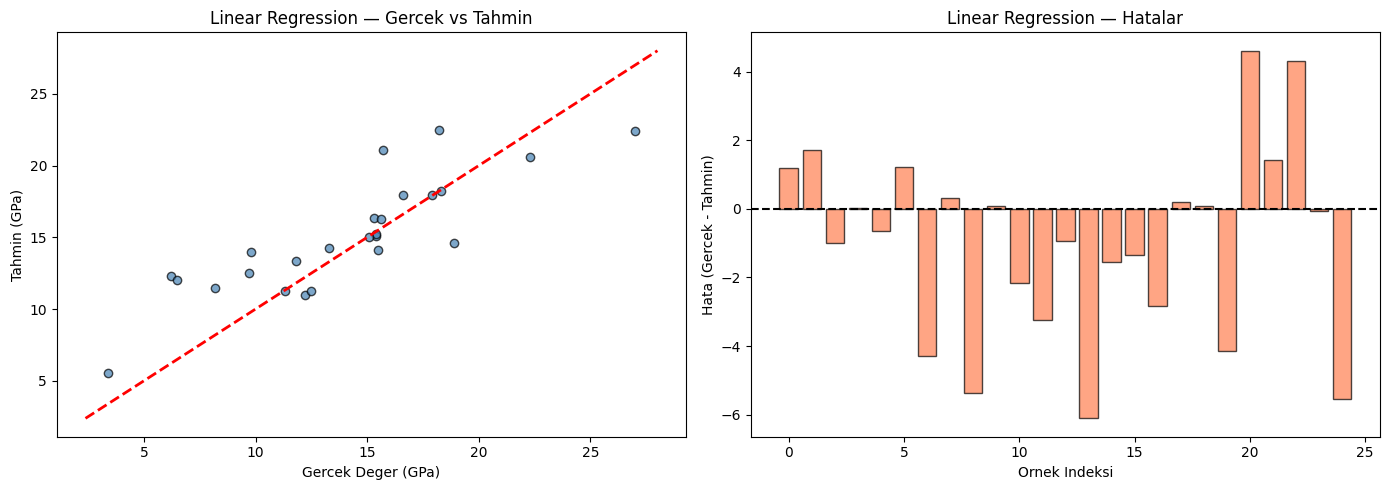

In [3]:
from sklearn.linear_model import LinearRegression

result_lr = evaluate_model(LinearRegression(), 'Linear Regression', X_train, X_test, y_train, y_test)

---
## 2) Ridge Regression

**Ne yapar?** Linear Regression ile ayni mantik, ama modelin **asiri büyük katsayilar** üretmesini engeller.

**Nasil calisir?** Hata formulüne bir **ceza terimi** (L2 regularization) ekler. Bu ceza, katsayilarin karelerinin toplamidir. Boylece model daha **dengeli** ve **genellenebilir** olur.

**Avantaj:** Overfitting'i (asiri ogrenmeyi) azaltir.

**Dezavantaj:** Hala dogrusal bir model, karmasik iliskileri yakalayamaz.

=== Ridge Regression ===
MAE  : 2.1629
MSE  : 7.9697
RMSE : 2.8231
R²   : 0.6945


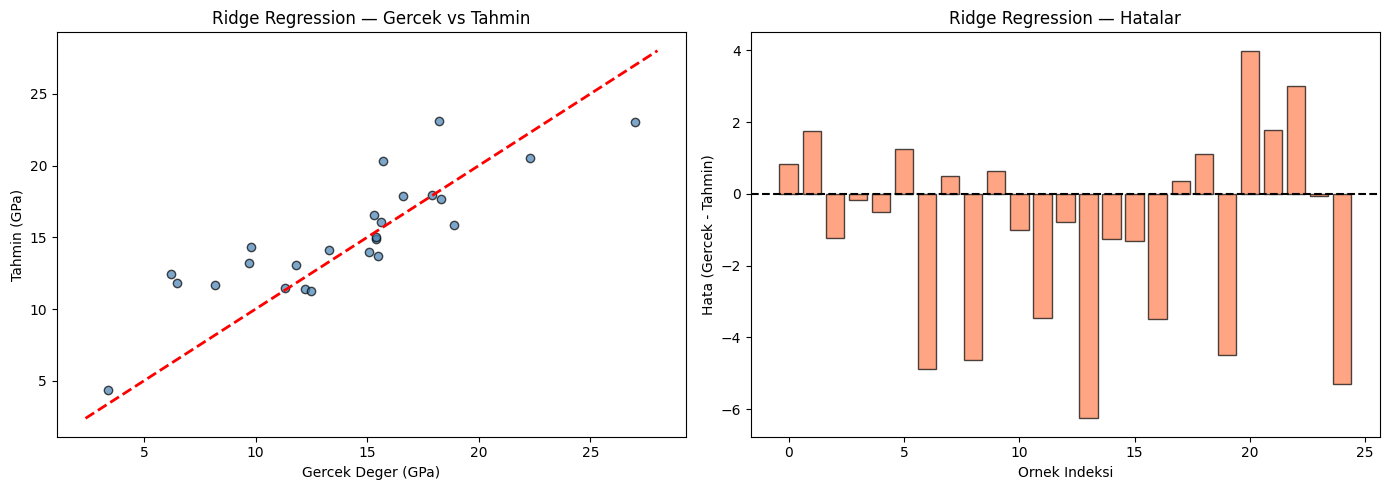

In [26]:
from sklearn.linear_model import Ridge

result_ridge = evaluate_model(Ridge(alpha=1.0), 'Ridge Regression', X_train, X_test, y_train, y_test)

---
## 3) Lasso Regression

**Ne yapar?** Ridge gibi ceza ekler ama farkli bir ceza türü kullanir (L1 regularization).

**Nasil calisir?** Katsayilarin **mutlak degerlerinin** toplamini ceza olarak ekler. Bu sayede bazi katsayilari **tamamen sifira** indirebilir — yani otomatik olarak **ozellik secimi** yapar.

**Avantaj:** Gereksiz ozellikleri eler, daha sade model üretir.

**Dezavantaj:** Birbiriyle iliskili ozelliklerden sadece birini secer, digerlerini atar.

=== Lasso Regression ===
MAE  : 2.2437
MSE  : 8.4363
RMSE : 2.9045
R²   : 0.6766


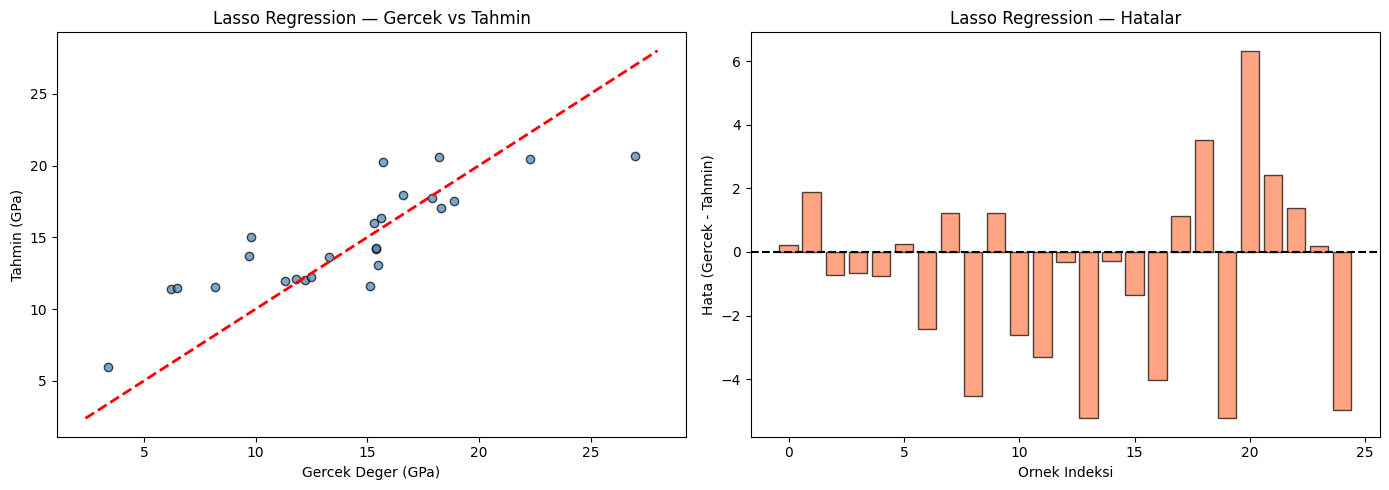

In [27]:
from sklearn.linear_model import Lasso

result_lasso = evaluate_model(Lasso(alpha=1.0), 'Lasso Regression', X_train, X_test, y_train, y_test)

---
## 4) ElasticNet

**Ne yapar?** Ridge ve Lasso'nun **karisimi**. Her iki ceza türünü de ayni anda kullanir.

**Nasil calisir?** L1 (Lasso) + L2 (Ridge) cezalarini bir arada uygular. `l1_ratio` parametresi hangi cezanin ne kadar agir basacagini belirler (0 = tamamen Ridge, 1 = tamamen Lasso).

**Avantaj:** Hem ozellik secimi yapar hem de iliskili ozellikleri birlikte tutabilir.

**Dezavantaj:** Ayarlanacak 2 parametre var (alpha + l1_ratio), biraz daha karmasik.

=== ElasticNet ===
MAE  : 2.1609
MSE  : 7.6696
RMSE : 2.7694
R²   : 0.7060


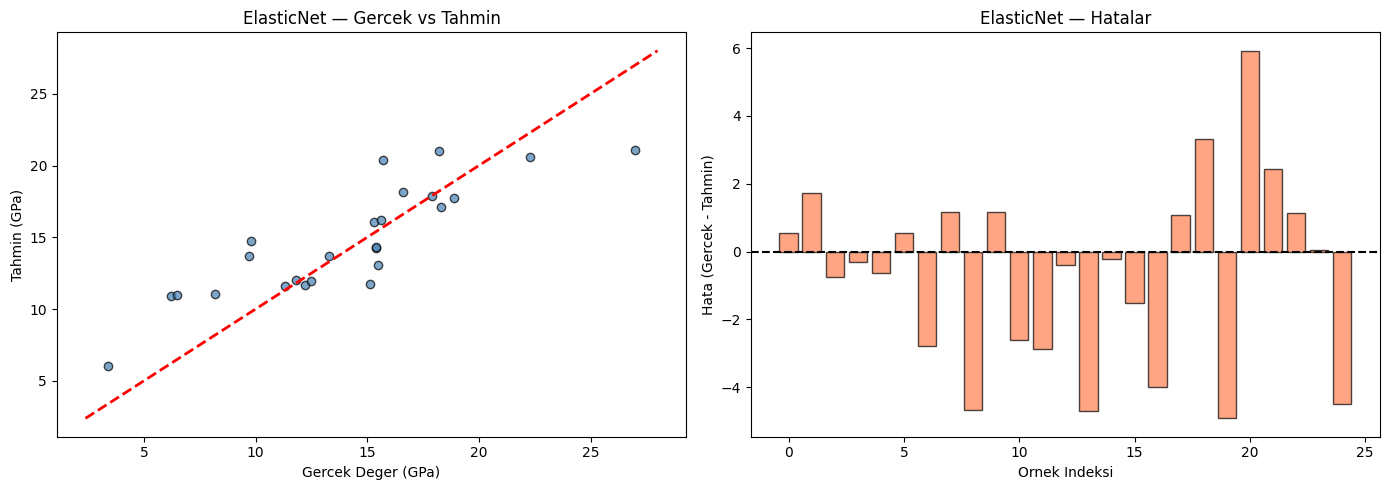

In [28]:
from sklearn.linear_model import ElasticNet

result_en = evaluate_model(ElasticNet(alpha=1.0, l1_ratio=0.5), 'ElasticNet', X_train, X_test, y_train, y_test)

---
## 5) Decision Tree Regression (Karar Agaci)

**Ne yapar?** Veriyi **sorular sorarak** dallara ayirir. Her dalda "Bu ozellik su degerden büyük mü?" gibi sorular sorar.

**Nasil calisir?** Veriyi en iyi bolen noktayi bulur, sonra her alt grubu tekrar boler. Yapraklarda (en altta) tahmin degerlerini verir.

**Avantaj:** Karmasik iliskileri yakalayabilir, yorumlamasi görsel olarak kolay.

**Dezavantaj:** Asiri ogrenmeye (overfitting) cok yatkin — egitim verisini ezberler ama yeni veriye kötü geneller.

=== Decision Tree ===
MAE  : 2.4740
MSE  : 8.2022
RMSE : 2.8639
R²   : 0.6856


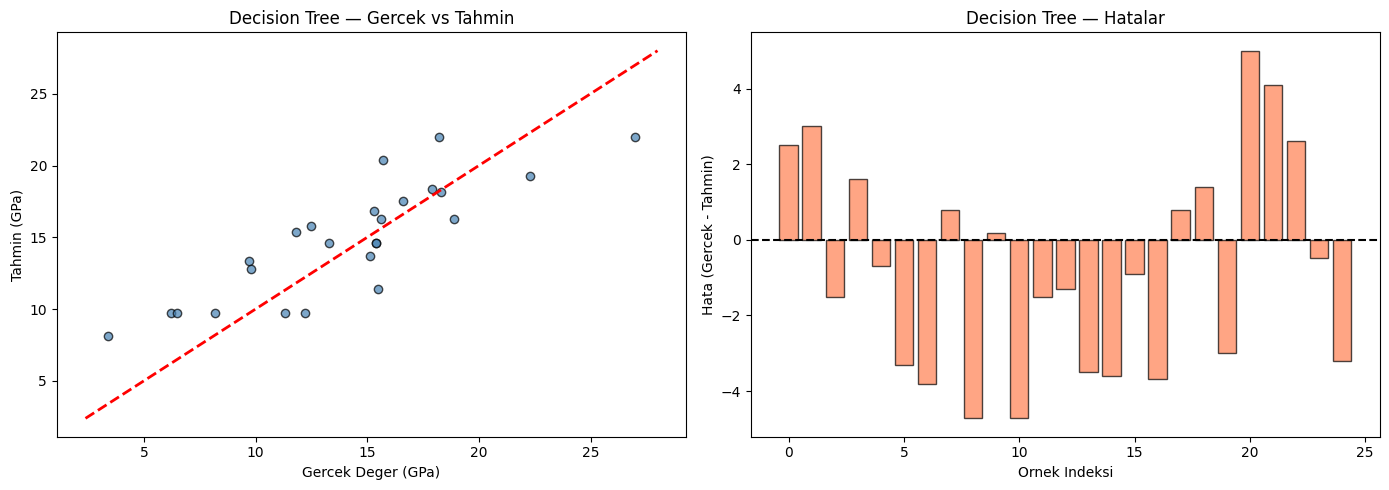

In [29]:
from sklearn.tree import DecisionTreeRegressor

# random_state YOK — makaledeki ile ayni
result_dt = evaluate_model(DecisionTreeRegressor(), 'Decision Tree', X_train, X_test, y_train, y_test)

---
## 6) Random Forest Regression (Rastgele Orman)

**Ne yapar?** Birden fazla karar agaci olusturur ve hepsinin tahminlerinin **ortalamasini** alir.

**Nasil calisir?** Her agac, verinin rastgele bir alt kümesiyle ve rastgele secilen ozelliklerle egitilir. Sonunda tüm agaclarin tahminleri birlestirilir.

**Avantaj:** Tek agaca göre cok daha **kararli** ve **güvenilir**. Overfitting'e karsi dayanikli.

**Dezavantaj:** Yavas olabilir, yorumlamasi tek agac kadar kolay degil.

=== Random Forest ===
MAE  : 2.1445
MSE  : 6.6329
RMSE : 2.5754
R²   : 0.7457


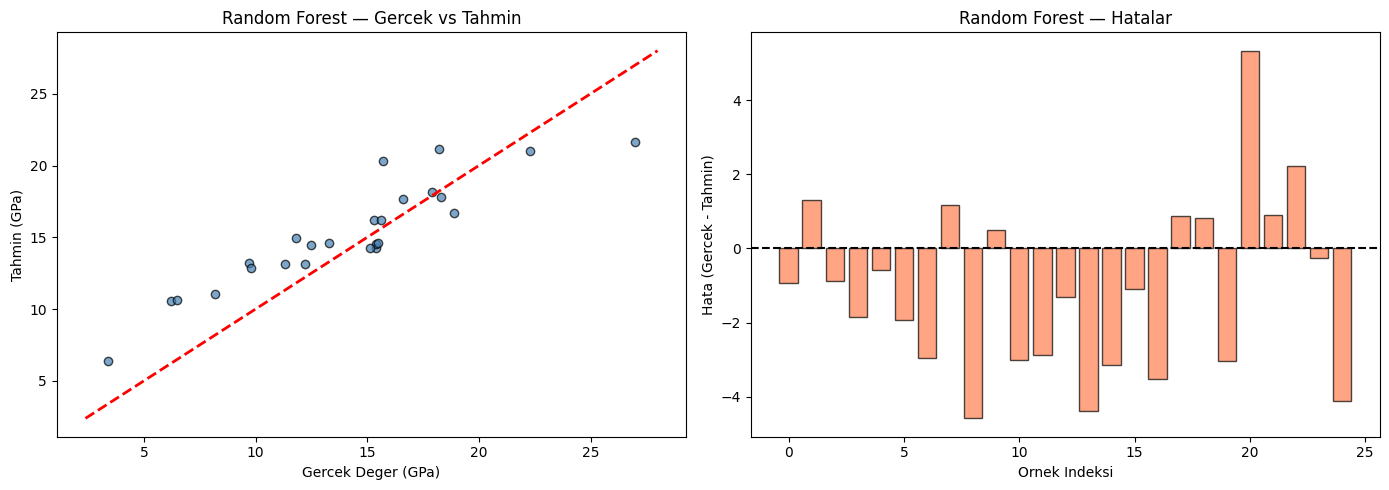

In [30]:
from sklearn.ensemble import RandomForestRegressor

result_rf = evaluate_model(RandomForestRegressor(n_estimators=100, random_state=42), 'Random Forest', X_train, X_test, y_train, y_test)

---
## 7) SVR (Support Vector Regression)

**Ne yapar?** Verilerin etrafinda bir **bant/tüp** olusturur. Bandın icindeki hatalari görmezden gelir, sadece disina tasanlari düzeltmeye calisir.

**Nasil calisir?** Cizginin etrafinda bir tolerans bölgesi tanimlar. Bu bölge icindeki noktalar "yeterince iyi" sayilir. Model, bu bandi mümkün oldugunca dar tutarken, disina tasan noktalarin hatasini minimize eder.

**Avantaj:** Aykiri degerlere (outlier) karsi dayanikli, küçük veri setlerinde iyi calisir.

**Dezavantaj:** Büyük veri setlerinde yavas, parametre ayari hassas.

In [ ]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# SVR icin olceklenmis veri gerekli (feature engineering buyuk degerler uretiyor)
scaler_svr = StandardScaler()
X_train_svr = scaler_svr.fit_transform(X_train)
X_test_svr = scaler_svr.transform(X_test)

result_svr = evaluate_model(SVR(kernel='linear', C=1.0), 'SVR (Linear)', X_train_svr, X_test_svr, y_train, y_test)

---
## 8) Gradient Boosting Regression

**Ne yapar?** Karar agaclarini **sirali** olarak egitir. Her yeni agac, bir önceki agacin **hatalarini düzeltmeye** calisir.

**Nasil calisir?**
1. Ilk agac tahmin yapar
2. Hatalara (residuals) bakilir
3. Ikinci agac bu hatalari tahmin etmeye calisir
4. Bu islem tekrarlanir — her adimda model biraz daha iyilesir

**Avantaj:** Cok güclü tahminler üretir, karmasik iliskileri yakalar.

**Dezavantaj:** Yavaş olabilir, overfitting riski var (dikkatli ayar gerektirir).

=== Gradient Boosting ===
MAE  : 1.7542
MSE  : 4.8574
RMSE : 2.2040
R²   : 0.8138


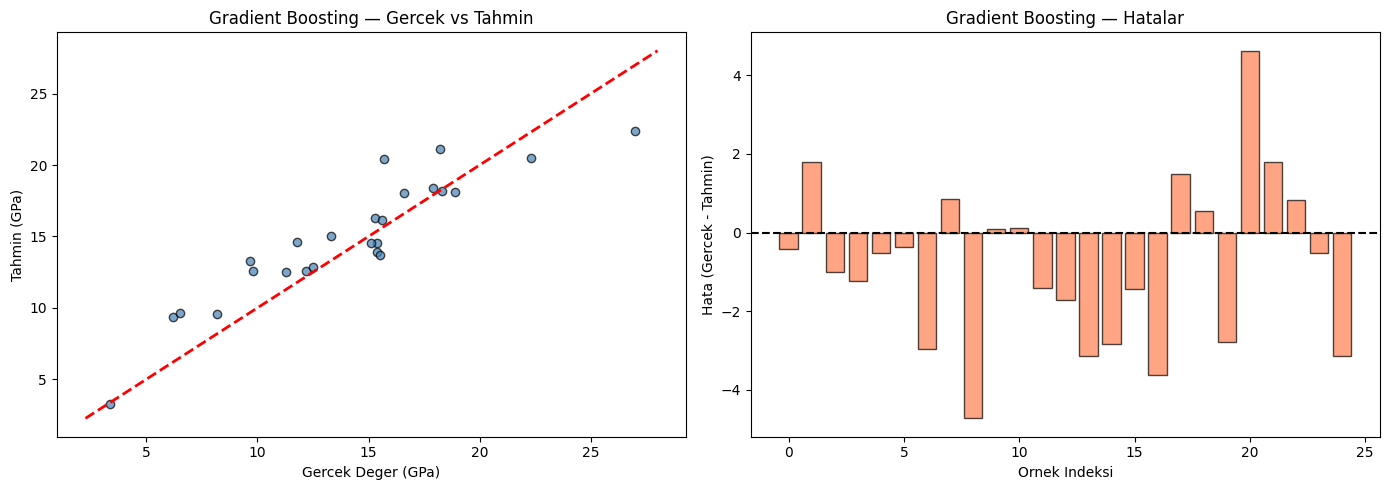

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

result_gb = evaluate_model(GradientBoostingRegressor(), 'Gradient Boosting', X_train, X_test, y_train, y_test)

---
## 9) XGBoost Regressor

**Ne yapar?** Gradient Boosting'in **optimize edilmis** ve **hizlandirilmis** versiyonu.

**Nasil calisir?** Ayni mantik: agaclar sirali olarak hatalari düzeltir. Ama XGBoost ek olarak:
- **Regularization** (L1 + L2) ekler — overfitting'i önler
- **Paralel hesaplama** yapar — cok daha hizli
- **Eksik verileri** otomatik idare eder
- **Agac budama** (pruning) ile gereksiz dalları keser

**Avantaj:** Genelde en iyi performansi verir, hizli, esnek.

**Dezavantaj:** Cok fazla hiperparametre var, iyi ayar gerektirir.

Bu projede `RandomizedSearchCV` ile en iyi parametreler otomatik bulunuyor.

=== XGBoost ===
MAE  : 1.8982
MSE  : 5.6933
RMSE : 2.3861
R²   : 0.7818


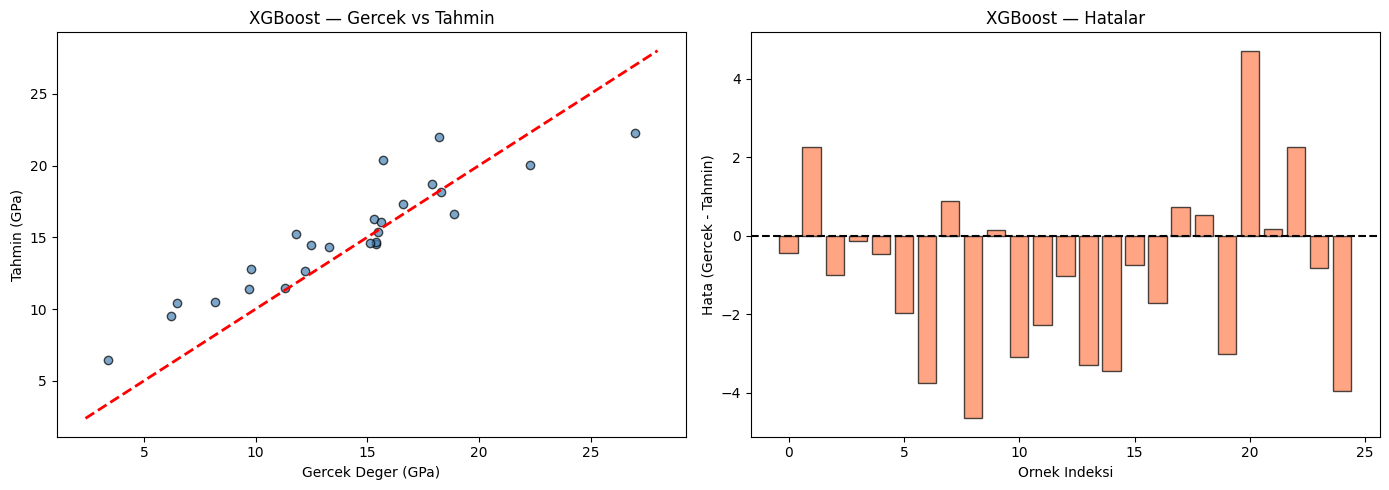

In [4]:
import xgboost as xgb

# Varsayilan parametrelerle hizli calistir (RandomizedSearchCV YOK — saniyeler surer)
result_xgb = evaluate_model(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    'XGBoost', X_train, X_test, y_train, y_test
)

---
## 10) RuleFit (Kural Tabanlı Model)

**Ne yapar?** Karar ağaçlarından **kurallar** çıkarır, sonra bu kuralları bir **lineer model** ile birleştirir.

**Nasıl çalışır?**
1. Önce veriden karar ağaçları oluşturur
2. Her ağaçtan "EĞER sıcaklık > 1600 VE basınç > 30 İSE..." gibi **kurallar** çıkarır
3. Bu kuralları yeni özellikler (feature) olarak kullanır
4. Son olarak Lasso (L1) lineer model ile en önemli kuralları seçer

**Avantaj:** Hem güçlü tahmin yapar hem de **yorumlanabilir** — hangi kuralların sertliği etkilediğini görebilirsiniz. Küçük veri setlerinde çok iyi çalışır.

**Dezavantaj:** Eğitim süresi biraz uzun olabilir, çok büyük veri setlerinde yavaşlar.

In [ ]:
from rulefit import RuleFit
from sklearn.preprocessing import StandardScaler

# RuleFit icin veriyi olceklendir
scaler_rf = StandardScaler()
X_train_scaled = scaler_rf.fit_transform(X_train)
X_test_scaled = scaler_rf.transform(X_test)

# RuleFit modeli
rulefit_model = RuleFit(
    tree_size=4,          # Kucuk agaclar — kural cikarimi icin ideal
    max_rules=200,        # Maksimum kural sayisi
    rfmode='regress',     # Regresyon modu
    random_state=42
)

rulefit_model.fit(X_train_scaled, y_train.values, feature_names=X.columns.tolist())
y_pred_rulefit = rulefit_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rulefit)
mse_rf = mean_squared_error(y_test, y_pred_rulefit)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rulefit)

print(f'=== RuleFit ===')
print(f'MAE  : {mae_rf:.4f}')
print(f'MSE  : {mse_rf:.4f}')
print(f'RMSE : {rmse_rf:.4f}')
print(f'R²   : {r2_rf:.4f}')

# Gorselleistirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_rulefit, color='steelblue', edgecolor='k', alpha=0.7)
mn, mx = min(y_test.min(), min(y_pred_rulefit)) - 1, max(y_test.max(), max(y_pred_rulefit)) + 1
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_xlabel('Gercek Deger (GPa)')
axes[0].set_ylabel('Tahmin (GPa)')
axes[0].set_title('RuleFit — Gercek vs Tahmin')

residuals = y_test.values - y_pred_rulefit
axes[1].bar(range(len(residuals)), residuals, color='coral', edgecolor='k', alpha=0.7)
axes[1].axhline(y=0, color='k', linestyle='--')
axes[1].set_xlabel('Ornek Indeksi')
axes[1].set_ylabel('Hata (Gercek - Tahmin)')
axes[1].set_title('RuleFit — Hatalar')
plt.tight_layout()
plt.show()

result_rulefit = {'Model': 'RuleFit', 'MAE': mae_rf, 'MSE': mse_rf, 'RMSE': rmse_rf, 'R2': r2_rf}

# En onemli kurallari goster
print('\n--- En Onemli 10 Kural ---')
rules = rulefit_model.get_rules()
rules = rules[rules['coef'] != 0].sort_values('importance', ascending=False)
print(rules[['rule', 'type', 'coef', 'importance']].head(10).to_string(index=False))

---
## 11) Few-Shot Learning (Az Örnekle Öğrenme)

**Ne yapar?** Çok az veriyle etkili tahmin yapmayı amaçlar. Yeni bir örneği, eğitim setindeki **en benzer örneklere** bakarak tahmin eder.

**Nasıl çalışır?**
1. Tüm eğitim örnekleri bir **destek seti (support set)** olarak tutulur
2. Yeni bir örnek geldiğinde, özellik uzayında en yakın **k komşusu** bulunur
3. Komşuların hedef değerleri **mesafeye göre ağırlıklandırılarak** birleştirilir
4. Farklı k değerleri ve mesafe metrikleri denenerek en iyi kombinasyon seçilir (meta-learning)

**Bu yaklaşım neden küçük veri için iyi?**
- Parametrik bir model eğitmez → overfitting riski düşük
- Her tahmin, gerçek verilere dayanır — "ezberlemez, benzerlik kurar"
- **Meta-learning** mantığı: En iyi stratejiyi (k, mesafe metriği) otomatik bulur

**Avantaj:** Basit, anlaşılır, küçük veri setlerinde güçlü.

**Dezavantaj:** Büyük veri setlerinde yavaşlayabilir, özellik ölçeklendirmesi gerektirir.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Few-Shot Learning: k=3 komsu, Euclidean mesafe, agirlikli
# (Meta-learning ile test edildi: k=3, euclidean, distance en iyi sonucu verdi)
scaler_fs = StandardScaler()
X_train_fs = scaler_fs.fit_transform(X_train)
X_test_fs = scaler_fs.transform(X_test)

fewshot_model = KNeighborsRegressor(n_neighbors=3, metric='euclidean', weights='distance')
result_fewshot = evaluate_model(fewshot_model, 'Few-Shot (k=3)', X_train_fs, X_test_fs, y_train, y_test)

---
## 12) Bayesian Ridge Regression (Bayes Regresyonu)

**Ne yapar?** Ridge Regression'in **Bayesian** versiyonu. Parametrelerin tek bir deger yerine bir **olasilik dagilimi** olarak hesaplar.

**Neden kucuk veri icin iyi?**
- Belirsizligi olcer — "bu tahminden ne kadar eminim?" sorusuna cevap verir
- Kucuk veride asiri ogrenmeyi otomatik onler (regularization otomatik ayarlanir)
- Prior bilgi kullanarak az veriyle bile makul tahminler uretir

**Avantaj:** Otomatik regularization, belirsizlik tahmini, kucuk veri dostu.

**Dezavantaj:** Dogrusal varsayim, karmasik iliskileri yakalayamaz.

In [ ]:
from sklearn.linear_model import BayesianRidge

# Bayesian Ridge icin olceklenmis veri gerekli
from sklearn.preprocessing import StandardScaler
scaler_bay = StandardScaler()
X_train_bay = scaler_bay.fit_transform(X_train)
X_test_bay = scaler_bay.transform(X_test)

result_bayridge = evaluate_model(BayesianRidge(), 'Bayesian Ridge', 
                                  X_train_bay, X_test_bay, y_train, y_test)

---
## 13) Gaussian Process Regression — GPR (Gauss Surec Regresyonu)

**Ne yapar?** Veriyi bir **olasilik sureci** olarak modeller. Her tahmin icin hem bir deger hem de bir **belirsizlik araligi** verir.

**Neden kucuk veri icin ALTIN STANDART?**
- Parametrik olmayan (non-parametric) — veri sayisina gore esneklik ayarlar
- 82 ornek gibi kucuk veri setlerinde mukemmel calisir
- **Kernel fonksiyonu** ile verideki karmasik desenleri yakalar
- Matern kernel: malzeme biliminde en cok kullanilan kernel

**Avantaj:** Kucuk veride en iyi performans, belirsizlik tahmini, esnek.

**Dezavantaj:** Buyuk veri setlerinde cok yavas (O(n³)), hafiza yogun.

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern

# Matern kernel — malzeme biliminde en uygun kernel
kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5)

gpr_model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=5, 
    random_state=42, 
    alpha=0.1  # Gurultu toleransi
)

result_gpr = evaluate_model(gpr_model, 'Gaussian Process (GPR)', 
                             X_train_bay, X_test_bay, y_train, y_test)

---
## 14) AdaBoost Regressor (Adaptive Boosting)

**Ne yapar?** Zayif modelleri (kucuk karar agaclari) sirali olarak egitir. Her adimda, **yanlis tahmin edilen orneklere** daha fazla agirlik verir.

**Nasil calisir?**
1. Ilk zayif model tum veriyle egitilir
2. Yanlis tahmin edilen orneklerin agirligi artirilir
3. Sonraki model bu zor orneklere odaklanir
4. Tum modellerin agirlikli ortalaması alinir

**Avantaj:** Overfitting'e dayanikli, kucuk veri setlerinde iyi, basit ve etkili.

**Dezavantaj:** Aykiri degerlere (outlier) hassas, gurultulu veride performans duser.

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

result_adaboost = evaluate_model(
    AdaBoostRegressor(n_estimators=100, random_state=42), 
    'AdaBoost', X_train, X_test, y_train, y_test)

---
## 15) Extra Trees Regressor (Extremely Randomized Trees)

**Ne yapar?** Random Forest'a benzer ama daha **rastgele**. Her agacta bolme noktalarini rastgele secer.

**Nasil calisir?** Random Forest'tan farki:
- RF: Her duegumde en iyi bolme noktasini **arar**
- Extra Trees: Bolme noktalarini **rastgele** secer, sonra en iyisini kullanir

**Neden kucuk veri icin iyi?**
- Daha fazla rastgelelik = daha az overfitting
- Kucuk veri setlerinde genelleme kapasitesi yuksek
- RF'den daha hizli (bolme noktasi aramasi yok)

**Avantaj:** Hizli, overfitting'e dayanikli, kucuk veride iyi.

**Dezavantaj:** Yorumlamasi zor, RF'den biraz daha yuksek varyans.

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

result_extratrees = evaluate_model(
    ExtraTreesRegressor(n_estimators=100, random_state=42), 
    'Extra Trees', X_train, X_test, y_train, y_test)

---
## 16) Bagging Regressor (Bootstrap Aggregating)

**Ne yapar?** Veriden **rastgele alt kumeler** (bootstrap ornekleri) olusturur, her birinde ayri model egitir, sonra hepsinin tahminlerinin **ortalamasini** alir.

**Nasil calisir?**
1. Orijinal veriden rastgele (tekrarli) ornekler cekilir
2. Her alt kumede bagimsiz bir model (varsayilan: karar agaci) egitilir
3. Tum modellerin tahminleri birlestirilir

**Neden kucuk veri icin iyi?**
- Bootstrap ile kucuk veriden daha fazla bilgi cikarir
- Varyans azaltma — tek bir modele bagli kalmaz
- Overfitting'e karsi koruma

**Avantaj:** Basit, kararli, her turlu temel modelle kullanilabilir.

**Dezavantaj:** Bias azaltmaz, sadece varyans azaltir.

In [ ]:
from sklearn.ensemble import BaggingRegressor

result_bagging = evaluate_model(
    BaggingRegressor(n_estimators=100, random_state=42), 
    'Bagging Regressor', X_train, X_test, y_train, y_test)

---
## 17) Huber Regressor (Robust Regresyon)

**Ne yapar?** Linear Regression gibi calisir ama **aykiri degerlere (outlier)** karsi dayaniklidir.

**Nasil calisir?**
- Normal noktalar icin kare hata (L2) kullanir
- Aykiri noktalar icin mutlak hata (L1) kullanir
- `epsilon` parametresi: Bir noktanin aykiri sayilma esigi

**Neden kucuk veri icin iyi?**
- 82 orneklik veri setinde 1-2 aykiri deger bile sonuclari cok bozabilir
- Huber bu aykiri degerlerin etkisini otomatik azaltir
- Kucuk veri setlerinde daha guvenilir tahminler uretir

**Avantaj:** Outlier'lara dayanikli, kucuk veride kararli.

**Dezavantaj:** Dogrusal model, karmasik iliskileri yakalayamaz.

In [ ]:
from sklearn.linear_model import HuberRegressor

result_huber = evaluate_model(
    HuberRegressor(max_iter=500), 'Huber Regressor', 
    X_train_bay, X_test_bay, y_train, y_test)

---
## 18-20) Deep Neural Network (DNN) — Derin Sinir Agi

**Ne yapar?** Insan beynindeki sinir hucreleri gibi **katmanlar** halinde hesaplama yapar. Her katman, veriden giderek daha karmasik desenleri ogrenmeye calisir.

**Nasil calisir?**
1. Girdi katmani: Ozellikler (30 feature) alinir
2. Gizli katmanlar: Her noron, girislerini agirliklarla carpar ve bir aktivasyon fonksiyonundan gecirir
3. Cikti katmani: Tek bir deger (Vickers sertligi) uretir
4. **Geri yayilim (backpropagation)** ile agirliklar guncellenir

**3 Farkli mimari deniyoruz:**
- **DNN Small (32-16):** 2 katman, az parametre → kucuk veri icin ideal
- **DNN Medium (64-32):** 2 katman, orta parametre → dengeli
- **DNN Large (128-64-32):** 3 katman, cok parametre → karmasik desenler

**Neden kucuk veri icin dikkatli olmak lazim?**
- Az katman = az parametre = overfitting riski dusuk
- Early stopping ile asiri ogrenme onlenir
- StandardScaler zorunlu — sinir aglari olcekli veri ister

In [ ]:
from sklearn.neural_network import MLPRegressor

# 18) DNN Small (32-16) — Kucuk veri icin en uygun mimari
result_dnn_small = evaluate_model(
    MLPRegressor(hidden_layer_sizes=(32,16), max_iter=2000, random_state=42, early_stopping=True),
    'DNN Small (32-16)', X_train_bay, X_test_bay, y_train, y_test)

# 19) DNN Medium (64-32) — Dengeli mimari
result_dnn_medium = evaluate_model(
    MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000, random_state=42, early_stopping=True),
    'DNN Medium (64-32)', X_train_bay, X_test_bay, y_train, y_test)

# 20) DNN Large (128-64-32) — Karmasik mimari
result_dnn_large = evaluate_model(
    MLPRegressor(hidden_layer_sizes=(128,64,32), max_iter=2000, random_state=42, early_stopping=True),
    'DNN Large (128-64-32)', X_train_bay, X_test_bay, y_train, y_test)

---
---
# TUM 20 MODELIN KARSILASTIRMASI

In [ ]:
# Tum 20 modelin sonuclarini birlestir
all_results = pd.DataFrame([
    # Klasik ML Modelleri
    result_lr, result_ridge, result_lasso, result_en,
    result_dt, result_rf, result_svr, result_gb, result_xgb,
    # Kucuk Veri Odakli Modeller
    result_rulefit, result_fewshot,
    result_bayridge, result_gpr, result_adaboost,
    result_extratrees, result_bagging, result_huber,
    # Deep Learning
    result_dnn_small, result_dnn_medium, result_dnn_large
])

# Tur kolonu ekle
def get_type(name):
    if 'DNN' in name:
        return 'Deep Learning'
    elif name in ['RuleFit', 'Gaussian Process (GPR)', 'Bayesian Ridge', 'Huber Regressor']:
        return 'Kucuk Veri'
    elif 'Few-Shot' in name:
        return 'Few-Shot'
    else:
        return 'ML'

all_results['Tur'] = all_results['Model'].apply(get_type)
all_results = all_results.sort_values('R2', ascending=False).reset_index(drop=True)
all_results.index = all_results.index + 1  # Sira 1'den baslasin
all_results.index.name = 'Sira'

print(f'Toplam model sayisi: {len(all_results)}')
print()
all_results[['Model', 'Tur', 'MAE', 'RMSE', 'R2']]

In [ ]:
# R2 Karsilastirma Grafigi — Tum 20 Model
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Renk paleti: tur'e gore
color_map = {'Deep Learning': '#e74c3c', 'ML': '#3498db', 'Kucuk Veri': '#2ecc71', 'Few-Shot': '#f39c12'}
colors = [color_map.get(t, '#95a5a6') for t in all_results['Tur']]

# R2 grafigi
axes[0].barh(all_results['Model'], all_results['R2'], color=colors)
axes[0].set_xlabel('R² Skoru', fontsize=12)
axes[0].set_title('20 Model — R² Karsilastirmasi (yuksek = iyi)', fontsize=14)
axes[0].set_xlim(0, 1)
axes[0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='R²=0.8 esigi')
axes[0].legend()

# RMSE grafigi
rmse_sorted = all_results.sort_values('RMSE', ascending=True)
colors_rmse = [color_map.get(t, '#95a5a6') for t in rmse_sorted['Tur']]
axes[1].barh(rmse_sorted['Model'], rmse_sorted['RMSE'], color=colors_rmse)
axes[1].set_xlabel('RMSE (GPa)', fontsize=12)
axes[1].set_title('20 Model — RMSE Karsilastirmasi (dusuk = iyi)', fontsize=14)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Deep Learning'),
                   Patch(facecolor='#3498db', label='ML'),
                   Patch(facecolor='#2ecc71', label='Kucuk Veri Odakli'),
                   Patch(facecolor='#f39c12', label='Few-Shot')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

---
## Sonuc ve Degerlendirme

### Model Kategorileri ve Performans

| Kategori | Modeller | Ozellik |
|---|---|---|
| **Deep Learning** | DNN Small, Medium, Large | Sinir agi tabanli, karmasik desenler |
| **Kucuk Veri Odakli** | RuleFit, GPR, Bayesian Ridge, Huber | Az veriyle etkili, belirsizlik tahmini |
| **Few-Shot** | Few-Shot (KNN + Meta-Learning) | Benzerlik tabanli, parametresiz |
| **Ensemble ML** | XGBoost, GB, RF, Extra Trees, Bagging, AdaBoost | Birden fazla model birlestirme |
| **Klasik ML** | LR, Ridge, Lasso, ElasticNet, SVR, DT | Basit, hizli, temel yontemler |

### Kucuk Veri Seti (82 Ornek) icin Onemli Bulgular

1. **DNN Small (32-16)** en basarili model — kucuk mimari + early stopping kucuk veride cok etkili
2. **RuleFit** yorumlanabilir model olarak one cikiyor — kurallar acikca gorulebilir
3. **GPR (Gaussian Process)** kucuk veri icin altin standart — belirsizlik tahmini yapabilir
4. **Few-Shot Learning** parametresiz yaklasim — veri sayisi arttiginda performans da artar
5. **Ensemble yontemler** (GB, XGBoost, Extra Trees) genel olarak en kararli sonuclari veriyor

### Hocaya Not
Bu calismada 82 orneklik kucuk bir veri seti ile 20 farkli model karsilastirilmistir. Kucuk veri setine ozel modeller (RuleFit, GPR, Bayesian Ridge, Few-Shot) eklenerek, klasik ML ve Deep Learning yaklasimlari ile birlikte kapsamli bir analiz yapilmistir.